<img src="Figures/top_ML.png" alt="Drawing" style="width: 1000px;"/>

# Regresión 

### Contenido

1. Regresión lineal
2. Regresión lineal con sklearn
3. Métricas evaluación
5. Visualización

## 1. Regresión lineal

**Notación para el modelo de regresión lineal**

En un modelo lineal, tendremos un prámetro $\textbf{y}$ que depende de manera lineal de varios covariantes $\textbf{x}_i$:

$$ \textbf{y}  =  a_1 \textbf{x}_1  + \dots + a_m \textbf{x}_{m} $$

Los términos $a_i$ serán los *parametros* del modelo o *coeficientes*.

Si lo escribimos de forma matricial:

$$ \textbf{y}  = X \textbf{w}$$

donde $$ \textbf{y} = \left( \begin{array}{c} y_1 \\ y_2 \\ \vdots \\ y_n \end{array} \right), 
 X = \left( \begin{array}{c} x_{11}  \dots x_{1m} \\ x_{21}  \dots x_{2m}\\ \vdots \\ x_{n1}  \dots x_{nm} \end{array} \right),
 \textbf{w} = \left( \begin{array}{c} a_1 \\ a_2 \\ \vdots \\ a_m \end{array} \right) $$
 
En un modelo de regresión lineal que solo dependa de una variable, tendremos:

$$ \textbf{y}  =  a_0+ a_1 \textbf{x}_1 $$

Con un parámetro $a_0$ llamado constante o corte con el eje de ordenadas.

Si tenemos una regresión multivariable, tendremos:
$$ \textbf{y} = a_1 \textbf{x}_1 + \dots + a_m \textbf{x}_m = X \textbf{w} $$


Vamos a ver algun ejemplo de manera gráfica

In [1]:
import matplotlib.pylab as plt
import numpy as np
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1, rc={"lines.linewidth": 2,'font.family': [u'times']})
%matplotlib inline 
plt.rc('font', size=12) 
plt.rc('figure', figsize = (12, 5))

Si creamos un conjunto de datos "aleatorios", y los graficamos:

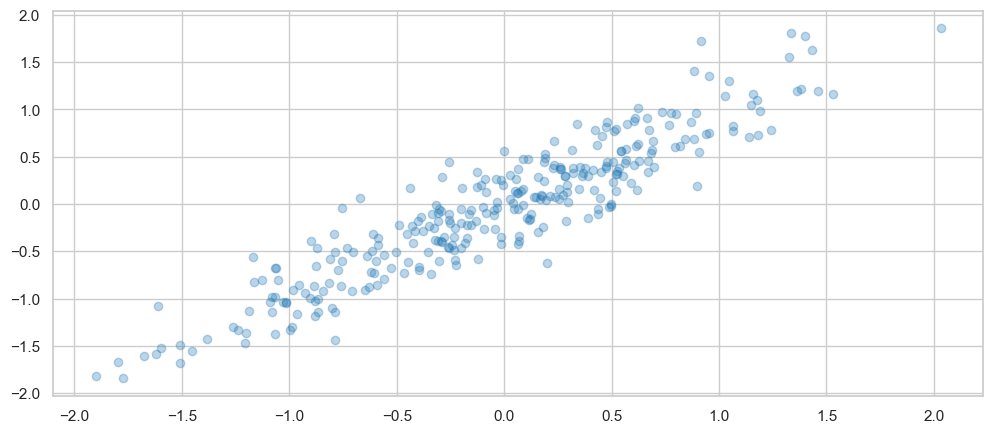

In [2]:
X1 = np.random.randn(300, 2)  # Aleatorios siguiendo una Gauss
A = np.array([[0.6, .4], [.4, 0.6]]) # Aplicació lineal per fer-la "una funció lineal"
X2 = np.dot(X1, A)
plt.plot(X2[:, 0], X2[:, 1], "o", alpha=0.3)

Está claro que hay una cierta correlación entre ellos que podríamos ver con este modelo:

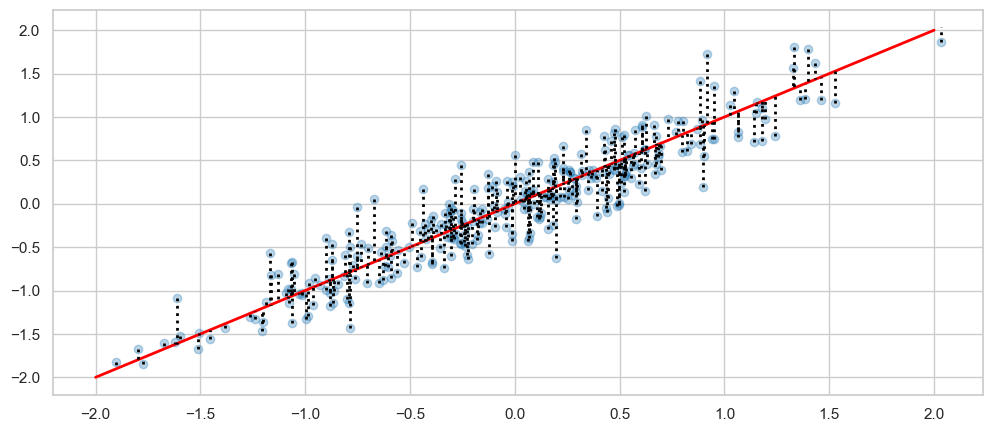

In [3]:
model=[0+1*x for x in np.arange(-2,3)] # un possible model

plt.plot(X2[:, 0], X2[:, 1], "o", alpha=0.3);
plt.plot(np.arange(-2,3), model,'r'); 
for xi, yi in zip(X2[:, 0],X2[:, 1]):
    plt.plot([xi]*2, [yi, 0+1*xi], "k:") # ilustrar errores
plt.show()


Pero, ¿Cuál es el modelo que mejor se ajusta a estos datos? 

¿Cómo encontramos los parámetros o coeficientes de la siguiente ecuación?

$$ \textbf{y}  =  a_0+ a_1 \textbf{x}_1 $$

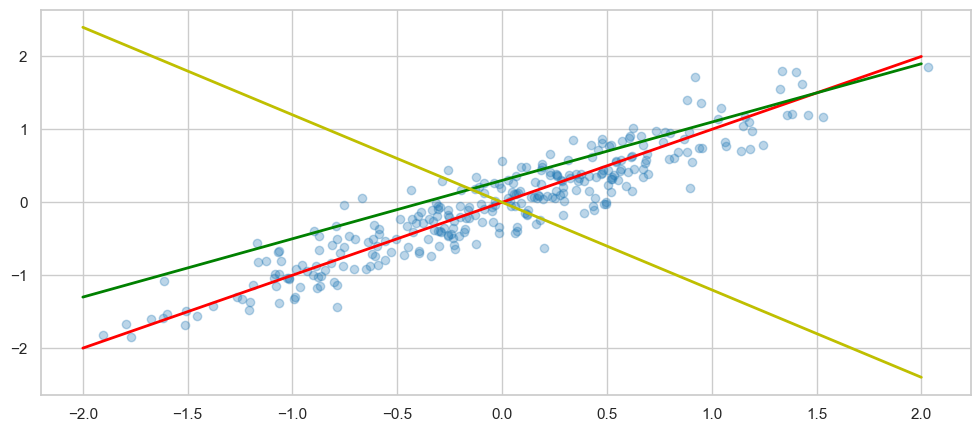

In [4]:
plt.plot(X2[:, 0], X2[:, 1], "o", alpha=0.3);
#más modelos!!
model1=[0+1*x for x in np.arange(-2,3)]
model2=[0.3+0.8*x for x in np.arange(-2,3)]
model3=[0-1.2*x for x in np.arange(-2,3)]
plt.plot(np.arange(-2,3), model1,'r')
plt.plot(np.arange(-2,3), model2,'g')
plt.plot(np.arange(-2,3), model3,'y')


El objetivo siempre será minimizar la suma del cuadrado de la distancia entro los puntos reales y el valor de la funcióm

Si tenemos los datos $(\textbf{x},\textbf{y})$, queremos minimizar:

$$ ||a_0 + a_1 \textbf{x} -  \textbf{y} ||^2_2 = \sum_{j=1}^n (a_0+a_1 x_{j} -  y_j )^2,$$ 

Esta expresión, se conoce como **sum of squared errors of prediction (SSE)**.

La manera más fàcil de encontrar estos dos parámetros es usando el algoritmo OLS (*Ordinary Least Squares*)

$$\textbf{y} = a_0+a_1 \textbf{x}$$



###  1.1 OLS

Veamos un ejemplo:

In [5]:
x = np.array([2.2, 4.3, 5.1, 5.8, 6.4, 8.0])
x_train = x.reshape(1,-1) 

y = np.array([0.4, 10.1, 14.0, 10.9, 15.4, 18.5])
y_train = y.reshape(1,-1)

Optimization terminated successfully.
         Current function value: 21.375000
         Iterations: 79
         Function evaluations: 153

SSE =  21.375000000874127

Modelo obtenido:
 -4.35 + 3.0 x


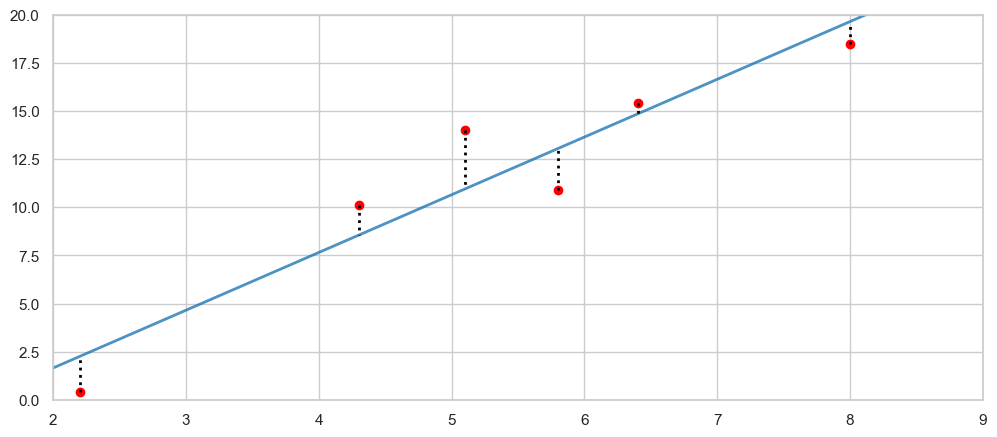

In [6]:
# Minimizar las distancias
from scipy.optimize import fmin

sse = lambda b, x, y: np.sum((y - b[0] - b[1]*x) ** 2) # Guardar la SSE

b0,b1 = fmin(sse, [0,1], args=(x,y)); # Minimizar usando 0 y 1 como valores iniciales de los coeficientes

plt.plot(x, y, 'ro')
plt.plot([0,10], [b0, b0+b1*10], alpha=0.8) # linia regresión
for xi, yi in zip(x,y):
    plt.plot([xi]*2, [yi, b0+b1*xi], "k:") # ilusrtrar errores
plt.xlim(2, 9); plt.ylim(0, 20)

print('\nSSE = ', np.sum((y - b0 - b1*x) ** 2))
print('\nModelo obtenido:\n',round(b0,2),'+',round(b1,2),'x')

También podríamos minimizar otros valores como  **suma del valor absoluto de las diferencias**. 

Optimization terminated successfully.
         Current function value: 10.162463
         Iterations: 39
         Function evaluations: 77

SSE =  33.54725815618215
Valores Absolutos =  10.162463486362249

Modelo obtenido:
 0.0 + 2.31 x


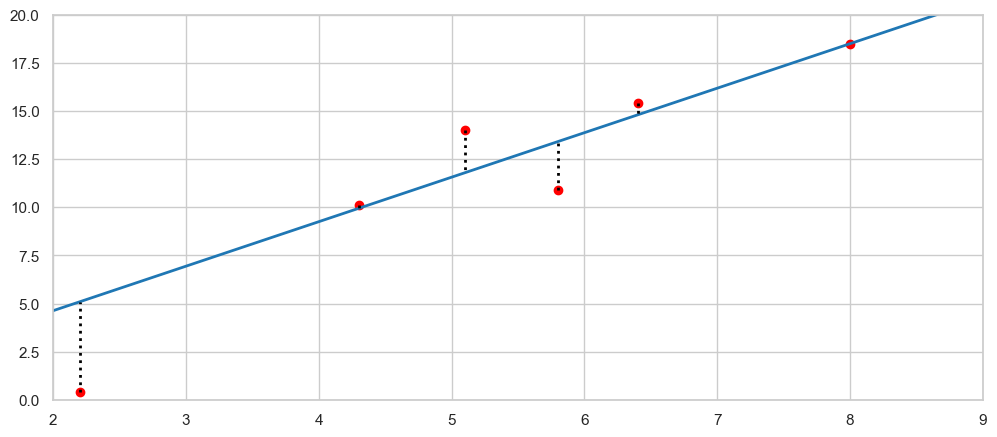

In [7]:
# Minimizar valores absolutos
from scipy.optimize import fmin

sabs = lambda b, x, y: np.sum(np.abs(y - b[0] - b[1]*x)) 

b0,b1 = fmin(sabs, [0,1], args=(x,y)) # Minimizar valores absolutos ahora

plt.plot(x, y, 'ro')
plt.plot([0,10], [b0, b0+b1*10]) # linia regresión
for xi, yi in zip(x,y):
    plt.plot([xi]*2, [yi, b0+b1*xi], "k:") # ilusrtrar errores
plt.xlim(2, 9); plt.ylim(0, 20) 

print('\nSSE = ', np.sum((y - b0 - b1*x) ** 2))
print('Valores Absolutos = ', np.sum(np.abs(y - b0 - b1*x)))
print('\nModelo obtenido:\n',round(b0,2),'+',round(b1,2),'x')

En este caso, penalizamos menos los valores lejanos.

Ventajas OLS

+ Fácil de calcular computacionalmente cuando son datasets pequeños. Para conjuntos más grandes el cálculo de una inversa provoca un aumento del tiempo de cómputo.
+ Fácil de interpretar

Y el modelo obtenido es:

$$\widehat{\textbf{y}} = \widehat{a}_0+\widehat{a}_1 \textbf{x}$$

Los sombreros indican que són valores estimados

### 2.Regresión lineal con Sklearn

Por suerte no tenemos que desarrollar estos algoritmos nosotros desde cero. Para esto están las librerías de machine learning ya hechas!!

Por ejemplo, veamos como de fácil es crear un modelo de regresión lineal en Sklearn, cargando un dataset de ejemplo de la librería:

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score

# Cargar dataset ejemplo
diabetes_X, diabetes_y = datasets.load_diabetes(return_X_y=True)
diabetes_X = diabetes_X[:, np.newaxis, 2]
diabetes_X_train = diabetes_X[:-20]
diabetes_X_test = diabetes_X[-20:]
diabetes_y_train = diabetes_y[:-20]
diabetes_y_test = diabetes_y[-20:]

Ahora, para ejecutar el modelo, es así de fácil:

a1 es: 
 [938.23786125]
a0 es: 
 152.91886182616113


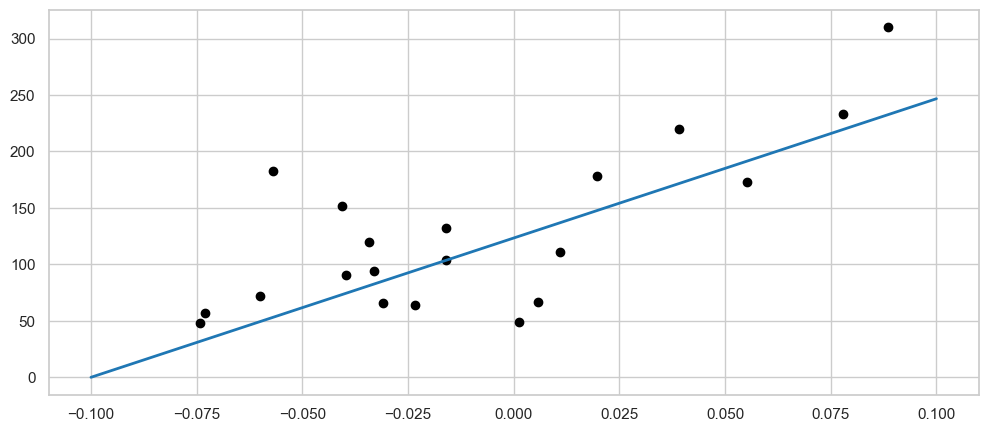

In [10]:
from sklearn.linear_model import LinearRegression

# Crear modelo regresion lineal
regr = LinearRegression()

# Entrear
regr.fit(diabetes_X_train, diabetes_y_train)

# Obtener modelo
print('a1 es: \n', regr.coef_)
print('a0 es: \n', regr.intercept_)

# Plot 
plt.scatter(diabetes_X_test, diabetes_y_test,  color='black')
plt.plot([-0.1,0.1], [b0, regr.intercept_+regr.coef_[0]*0.1]) # linia regresión

Une vez obtenido el modelo también podemos hacer predicciones directamente:

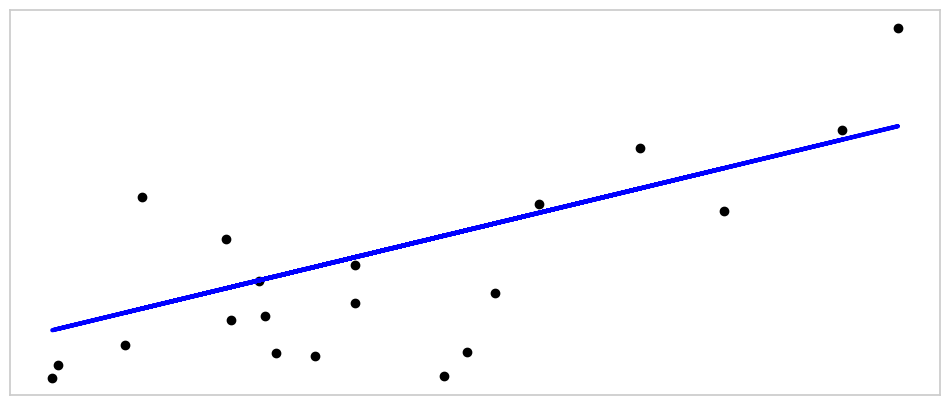

In [11]:
# Hacer predicciones
diabetes_y_pred = regr.predict(diabetes_X_test)

# Plot 
plt.scatter(diabetes_X_test, diabetes_y_test,  color='black')
plt.plot(diabetes_X_test, diabetes_y_pred, color='blue', linewidth=3)

plt.xticks(())
plt.yticks(())

plt.show()

## 3.Métricas de evaluación

Se puede evaluar el modelo obtenido calculando el **mean squared error** ($MSE$) y el **coeficiente de determinación** $R^2$

El MSE, se calcula como:

$$MSE=\frac{1}{n} \sum_{i=1}^n (\widehat{y}^i-y^i)^2,$$ 

El coeficiente $R^2$ se define 
$$(1 - \textbf{u}/\textbf{v})$$, donde $\textbf{u}$ es la suma de los cuadrados de los errores: $$\textbf{u}=\sum (\textbf{y} - \widehat{\textbf{y}} )^2$$ 
donde ${\textbf{y}}$ son los valores observados y  $\widehat{\textbf{y}}$ los valores de la predicción.

Y $\textbf{v}$ es el total de la suma de los cuadrado: $$\textbf{v}=\sum (\textbf{y} - \bar{\textbf{y}})^2,$$ donde $\bar{\textbf{y}}$ es la media de los datos observados.


En Sklearn, podríamos hacer:

In [12]:
from sklearn.metrics import mean_squared_error, r2_score

print('Mean squared error (MSE): %.2f'
      % mean_squared_error(diabetes_y_test, diabetes_y_pred))
# The coefficient of determination: 1 is perfect prediction
print('Coeficiente de determinación: %.2f'
      % r2_score(diabetes_y_test, diabetes_y_pred))

Mean squared error (MSE): 2548.07
Coeficiente de determinación: 0.47


## 4. Visualización

Podemos usar la función ``lmplot()`` de Seaborn para visualizar relaciones lineales de datasets multidimensionales. El input debe ser en *Pandas* .

### Ejemplo 1:  Macroeconomic dataset



In [13]:
import pandas as pd
# Read data
df = pd.read_csv('http://vincentarelbundock.github.io/Rdatasets/csv/datasets/longley.csv', index_col=0)
df.head()

,GNP.deflator,GNP,Unemployed,Armed.Forces,Population,Year,Employed
rownames,,,,,,,
1947,83.0,234.289,235.6,159.0,107.608,1947,60.323
1948,88.5,259.426,232.5,145.6,108.632,1948,61.122
1949,88.2,258.054,368.2,161.6,109.773,1949,60.171
1950,89.5,284.599,335.1,165.0,110.929,1950,61.187
1951,96.2,328.975,209.9,309.9,112.075,1951,63.221


Macroeconomic data from 1947 to 1962.

Queremos predecir  ('Employed') como respuesta $\textbf{y}$ usando ('GNP') como predictor $\textbf{x}$.



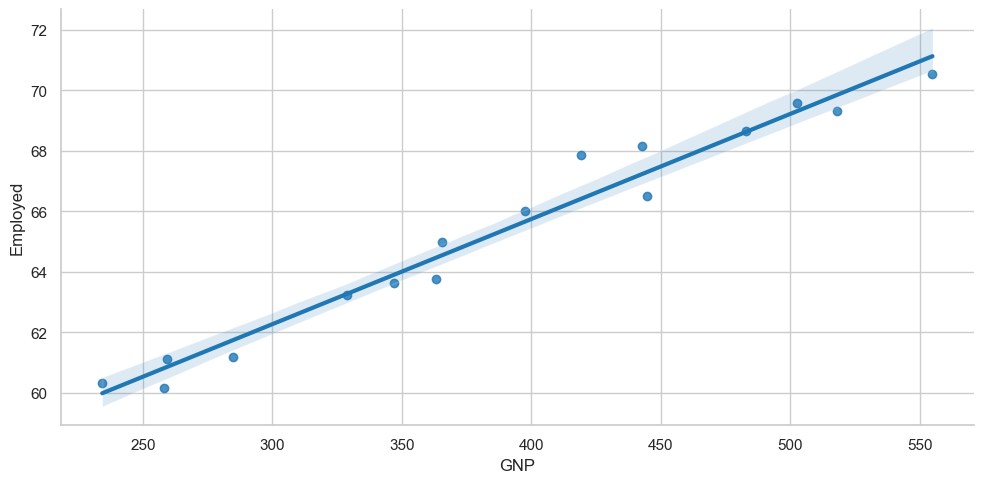

In [16]:
sns.lmplot(x="GNP", y="Employed", data=df, aspect=2)

Vemos
+ los puntos observador en scatterplot
+ La línia de regresión obtenida con un intervalo de confianza de un 95%.

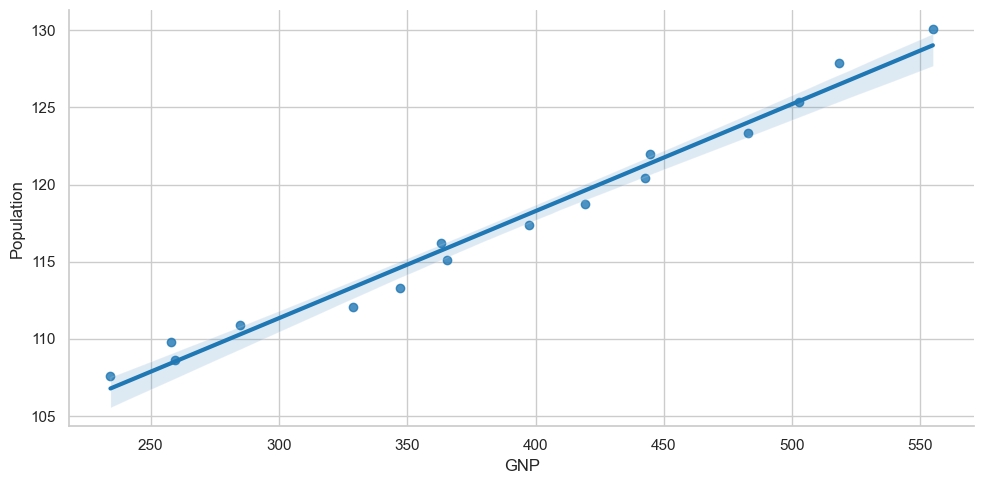

In [18]:
sns.lmplot(x="GNP", y="Population", data=df, aspect=2);

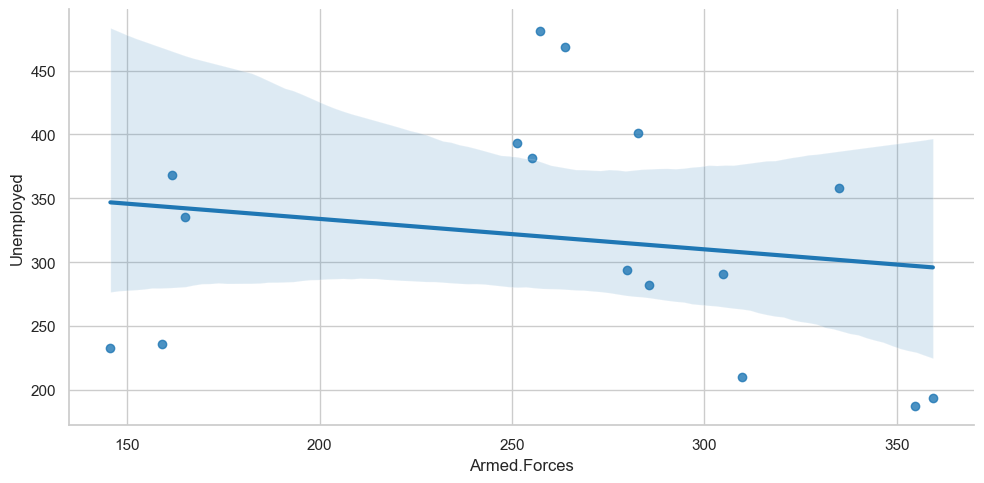

In [19]:
sns.lmplot(x="Armed.Forces", y="Unemployed", data=df, aspect=2);

Vemos que hay partes poco "lineales".

Para ello podemos usar la regresión polinomial.

